In [4]:
# --- Step 0: Install dependencies if needed ---
# pip install ultralytics opencv-python pandas scikit-learn --quiet

import os
import shutil
import random
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Step 1: Set paths ---
DATASET_PATH = r"C:\Users\Yannick\Documents\lego_dataset"           # root of your dataset
CROPPED_PATH = os.path.join(DATASET_PATH, "cropped_images")         # where the cropped images are
CSV_PATH = os.path.join(DATASET_PATH, "ImageSetKey.csv")            # the CSV mapping
OUT_PATH = r"C:\Users\Yannick\Documents\lego_yolo"                  # output path for YOLO

# --- Step 2: Create YOLO folders ---
for d in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(OUT_PATH, d), exist_ok=True)

# --- Step 3: Read CSV and build mapping ---
df = pd.read_csv(CSV_PATH)
print("CSV Columns:", df.columns)

# Mapping cropped images to classes using Folder2 as class
image_to_class = dict(zip(df['Name'], df['Folder2']))  
CLASS_NAMES = sorted(df['Folder2'].unique())
NC = len(CLASS_NAMES)  # number of classes
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

# Collect all image paths with class labels
all_items = []
for img_name, cls_name in image_to_class.items():
    img_path = os.path.join(CROPPED_PATH, cls_name, img_name)  # full path
    if os.path.exists(img_path):
        all_items.append((cls_name, img_path))
    else:
        print("WARNING: Missing image:", img_path)

# --- Step 4: Split train/val ---
train_items, val_items = train_test_split(
    all_items, test_size=0.2, stratify=[c for c,_ in all_items], random_state=42
)

# --- Step 5: Function to copy images and create YOLO labels ---
def convert_and_copy(items, img_dir, lbl_dir):
    for cls, img_path in items:
        fname = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(img_dir, fname))
        cls_idx = class_to_idx[cls]
        h, w = cv2.imread(img_path).shape[:2]
        # YOLO full-image bbox
        with open(os.path.join(lbl_dir, fname.rsplit(".",1)[0] + ".txt"), "w") as f:
            f.write(f"{cls_idx} 0.5 0.5 1.0 1.0\n")

convert_and_copy(train_items, os.path.join(OUT_PATH, "images/train"), os.path.join(OUT_PATH, "labels/train"))
convert_and_copy(val_items, os.path.join(OUT_PATH, "images/val"), os.path.join(OUT_PATH, "labels/val"))

# --- Step 6: Create data.yaml ---
yaml_text = f"""
train: {os.path.join(OUT_PATH, 'images/train')}
val:   {os.path.join(OUT_PATH, 'images/val')}

nc: {NC}
names: {CLASS_NAMES}
"""

with open(os.path.join(OUT_PATH, "data.yaml"), "w") as f:
    f.write(yaml_text)

print("✅ YOLO dataset ready with", NC, "classes")
print("Images stored in:", os.path.join(OUT_PATH, "images"))
print("Labels stored in:", os.path.join(OUT_PATH, "labels"))
print("YAML file:", os.path.join(OUT_PATH, "data.yaml"))


CSV Columns: Index(['Folder1', 'Folder2', 'Name', 'Brick Type'], dtype='object')
✅ YOLO dataset ready with 20 classes
Images stored in: C:\Users\Yannick\Documents\lego_yolo\images
Labels stored in: C:\Users\Yannick\Documents\lego_yolo\labels
YAML file: C:\Users\Yannick\Documents\lego_yolo\data.yaml


Selected image: D:/Downloads/lego-spare-parts-brick-2x2-red.jpg
Predicted class: Brick_2x4 (confidence: 0.11)


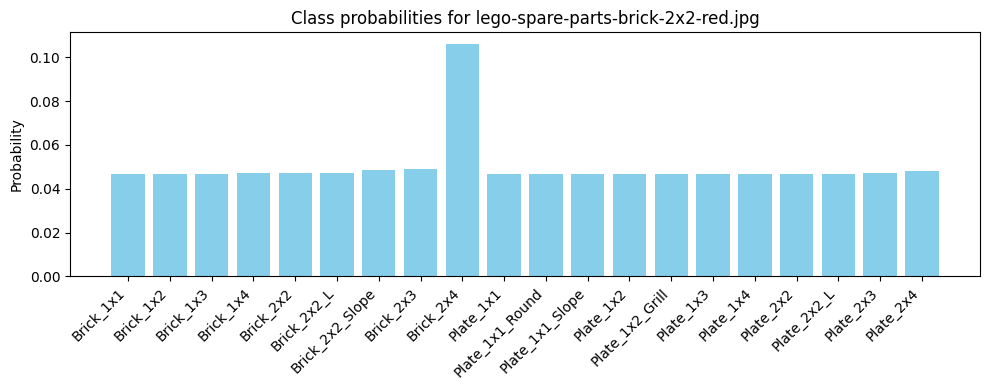

In [14]:
from ultralytics import YOLO
import torch
from PIL import Image
import torchvision.transforms as T
import tkinter as tk
from tkinter import filedialog
import numpy as np
import matplotlib.pyplot as plt

# --- Load your trained model ---
model_path = r"C:\Users\Yannick\Documents\lego_yolo\lego_exp10\weights\best.pt"
model = YOLO(model_path)

# --- File dialog ---
def select_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    file_path = filedialog.askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")]
    )
    root.destroy()
    return file_path

img_path = select_image()
if not img_path:
    print("No file selected. Exiting.")
    exit()
print("Selected image:", img_path)

# --- Preprocess image ---
img = Image.open(img_path).convert("RGB")
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# --- Run model to get raw logits ---
with torch.no_grad():
    preds = model.model(img_tensor)  # raw outputs from the model
    if isinstance(preds, (list, tuple)):
        preds = preds[0]  # YOLO sometimes returns a tuple
    logits = preds.cpu().numpy().squeeze()  # convert to numpy, remove batch dim

# --- Compute softmax probabilities ---
exp_logits = np.exp(logits - np.max(logits))
probs = exp_logits / exp_logits.sum()

# --- Get top prediction ---
pred_idx = int(np.argmax(probs))
pred_class = model.names[pred_idx]
pred_conf = probs[pred_idx]

print(f"Predicted class: {pred_class} (confidence: {pred_conf:.2f})")

# --- Plot all class probabilities ---
plt.figure(figsize=(10, 4))
plt.bar(range(len(probs)), probs, color='skyblue')
plt.xticks(range(len(probs)), [model.names[i] for i in range(len(probs))], rotation=45, ha='right')
plt.title(f"Class probabilities for {img_path.split('/')[-1]}")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()


In [15]:
from ultralytics import YOLO

# Start with pretrained classification weights
model = YOLO("yolov8n-cls.pt")

# Train directly from dataset folder (not YAML)
model.train(
    data=r"C:\Users\Yannick\Documents\lego-yolo",  # point to folder!
    epochs=30,
    imgsz=640,
    batch=16,
    project=r"C:\Users\Yannick\Documents\lego_yolo",
    name="lego_exp"
)


Ultralytics 8.3.204  Python-3.13.7 torch-2.8.0+cpu CPU (AMD Ryzen 9 4900HS with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Yannick\Documents\lego-yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=lego_exp10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000029AB837C050>
curves: []
curves_results: []
fitness: 0.8166666626930237
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.675000011920929, 'metrics/accuracy_top5': 0.9583333134651184, 'fitness': 0.8166666626930237}
save_dir: WindowsPath('C:/Users/Yannick/Documents/lego_yolo/lego_exp10')
speed: {'preprocess': 0.0012058299034833908, 'inference': 26.716884169339515, 'loss': 3.7501255671183266e-05, 'postprocess': 9.833408209184805e-05}
task: 'classify'
top1: 0.675000011920929
top5: 0.9583333134651184

In [ ]:
# --- Step 4: Create data.yaml ---
yaml_text = f"""
train: {IMG_DIR_TRAIN}
val: {IMG_DIR_VAL}

nc: {NC}
names: {CLASS_NAMES}
"""

with open(f"{OUT_PATH}/data.yaml", "w") as f:
    f.write(yaml_text)

print("✅ Dataset ready with", NC, "classes:", CLASS_NAMES)

In [19]:
from pathlib import Path
import random

# --- Config ---
SRC_DIR = Path(r"C:\Users\Yannick\Documents\lego_dataset\cropped_images")
DST_DIR = Path(r"C:\Users\Yannick\Documents\lego-small")
MAX_PER_CLASS = 30  # Keep only this many images per class

DST_DIR.mkdir(exist_ok=True)

for cls_path in SRC_DIR.iterdir():
    if not cls_path.is_dir():
        continue
    dst_cls = DST_DIR / cls_path.name
    dst_cls.mkdir(exist_ok=True)

    images = [*cls_path.glob("*.jpg"), *cls_path.glob("*.png"), *cls_path.glob("*.jpeg")]
    print(f"Checking {cls_path.name}: found {len(images)} images")
    if not images:
        continue

    # Pick only MAX_PER_CLASS images randomly
    for img_path in random.sample(images, min(MAX_PER_CLASS, len(images))):
        dst_file = dst_cls / img_path.name
        dst_file.write_bytes(img_path.read_bytes())  # Just copy file without modifying

print(f"✅ Done! Dataset reduced, smalled and saved at {DST_DIR}")


Checking Brick_1x1: found 216 images
Checking Brick_1x2: found 239 images
Checking Brick_1x3: found 188 images
Checking Brick_1x4: found 238 images
Checking Brick_2x2: found 235 images
Checking Brick_2x2_L: found 317 images
Checking Brick_2x2_Slope: found 192 images
Checking Brick_2x3: found 202 images
Checking Brick_2x4: found 242 images
Checking Plate_1x1: found 291 images
Checking Plate_1x1_Round: found 212 images
Checking Plate_1x1_Slope: found 329 images
Checking Plate_1x2: found 207 images
Checking Plate_1x2_Grill: found 217 images
Checking Plate_1x3: found 199 images
Checking Plate_1x4: found 223 images
Checking Plate_2x2: found 207 images
Checking Plate_2x2_L: found 224 images
Checking Plate_2x3: found 189 images
Checking Plate_2x4: found 213 images
✅ Done! Dataset reduced, smalled and saved at C:\Users\Yannick\Documents\lego-small


In [ ]:
# --- Step 6: Validate ---
metrics = model.val()
print(metrics)

SyntaxError: invalid syntax (1100450321.py, line 1)

In [20]:
import os, shutil, random
from glob import glob

SRC_DIR =  r"C:\Users\Yannick\Documents\lego-small"
DST_DIR = r"C:\Users\Yannick\Documents\lego-yolo"
VAL_RATIO = 0.2  # 20% validation

for split in ["train", "val"]:
    for cls in os.listdir(SRC_DIR):
        os.makedirs(os.path.join(DST_DIR, split, cls), exist_ok=True)

for cls in os.listdir(SRC_DIR):
    cls_path = os.path.join(SRC_DIR, cls)
    images = glob(os.path.join(cls_path, "*.jpg"))
    random.shuffle(images)

    split_idx = int(len(images) * (1 - VAL_RATIO))
    train_imgs, val_imgs = images[:split_idx], images[split_idx:]

    for img in train_imgs:
        shutil.copy(img, os.path.join(DST_DIR, "train", cls, os.path.basename(img)))
    for img in val_imgs:
        shutil.copy(img, os.path.join(DST_DIR, "val", cls, os.path.basename(img)))

print("✅ Dataset split into train/val at lego-yolo/")


✅ Dataset split into train/val at lego-yolo/


✅ Model loaded.
📦 Found 120 images across 20 classes.

🎯 Precision per class:
  Brick_1x1: 0.33
  Brick_1x2: 0.25
  Brick_1x3: 1.00
  Brick_1x4: 0.40
  Brick_2x2: 0.50
  Brick_2x2_L: 0.55
  Brick_2x2_Slope: 0.80
  Brick_2x3: 0.00
  Brick_2x4: 0.46
  Plate_1x1: 0.83
  Plate_1x1_Round: 1.00
  Plate_1x1_Slope: 0.75
  Plate_1x2: 0.00
  Plate_1x2_Grill: 0.86
  Plate_1x3: 0.00
  Plate_1x4: 0.50
  Plate_2x2: 0.75
  Plate_2x2_L: 0.56
  Plate_2x3: 0.57
  Plate_2x4: 0.60

📊 Macro-average precision: 0.54

Detailed report:
                 precision    recall  f1-score   support

      Brick_1x1       0.33      0.17      0.22         6
      Brick_1x2       0.25      0.17      0.20         6
      Brick_1x3       1.00      0.17      0.29         6
      Brick_1x4       0.40      0.67      0.50         6
      Brick_2x2       0.50      0.33      0.40         6
    Brick_2x2_L       0.55      1.00      0.71         6
Brick_2x2_Slope       0.80      0.67      0.73         6
      Brick_2x3       0.00

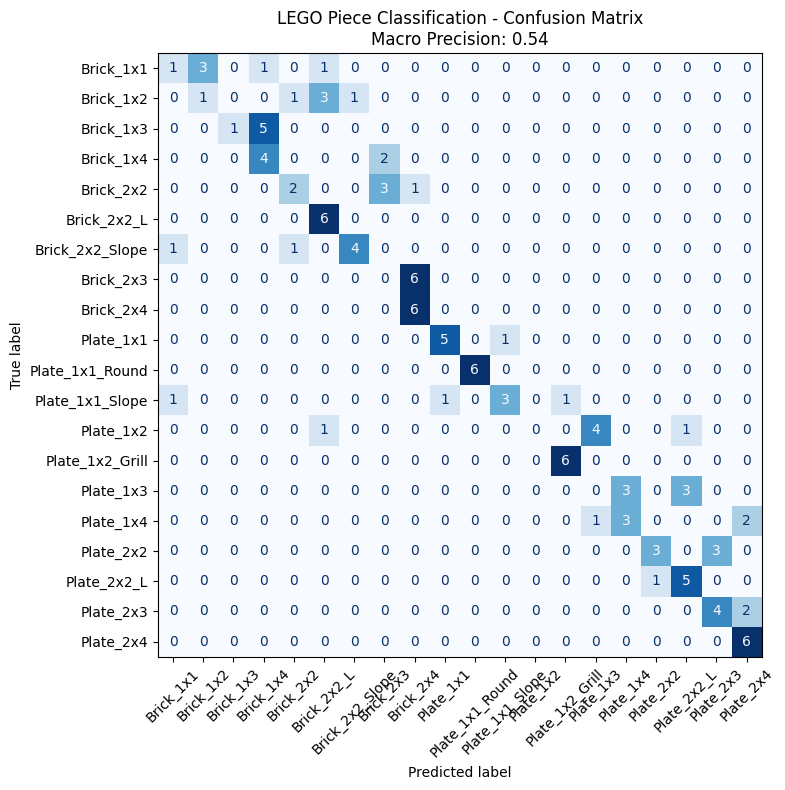

In [8]:
from ultralytics import YOLO
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import os
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- CONFIG ---
MODEL_PATH = r"C:\Users\Yannick\Documents\lego_yolo\lego_exp10\weights\best.pt"
DATASET_DIR = r"C:\Users\Yannick\Documents\lego-yolo\val"  # path to validation/test folder
IMG_SIZE = 640

# --- Load model ---
model = YOLO(MODEL_PATH)
print("✅ Model loaded.")

# --- Image transform ---
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

# --- Collect all images and labels ---
image_paths, true_labels = [], []
for cls_name in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls_name)
    if not os.path.isdir(cls_path):
        continue
    for f in os.listdir(cls_path):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_path, f))
            true_labels.append(cls_name)

print(f"📦 Found {len(image_paths)} images across {len(set(true_labels))} classes.")

# --- Predict ---
pred_labels = []
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        preds = model.model(img_tensor)
        if isinstance(preds, (list, tuple)):
            preds = preds[0]
        logits = preds.cpu().numpy().squeeze()

    pred_idx = int(np.argmax(logits))
    pred_class = model.names[pred_idx]
    pred_labels.append(pred_class)

# --- Prepare class list ---
classes = sorted(list(set(true_labels + pred_labels)))

# --- Compute metrics ---
cm = confusion_matrix(true_labels, pred_labels, labels=classes)
precision_per_class = precision_score(true_labels, pred_labels, labels=classes, average=None, zero_division=0)
macro_precision = precision_score(true_labels, pred_labels, average="macro", zero_division=0)

print("\n🎯 Precision per class:")
for cls_name, prec in zip(classes, precision_per_class):
    print(f"  {cls_name}: {prec:.2f}")

print(f"\n📊 Macro-average precision: {macro_precision:.2f}")

# --- Full classification report (optional) ---
print("\nDetailed report:")
print(classification_report(true_labels, pred_labels, digits=2, zero_division=0))

# --- Confusion matrix visualization ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"LEGO Piece Classification - Confusion Matrix\nMacro Precision: {macro_precision:.2f}")
plt.tight_layout()
plt.show()
